## Stabilitas
## Stabilitas Persamaan Panas: Perspektif Method of Lines

Dari perspektif method of lines, diskritisasi persamaan panas bisa dipandang
sebagai pertanyaan: apakah nilai $z = \Delta t \cdot \lambda$ berada di dalam
wilayah stabilitas metode ODE yang kita pilih? Di sinilah nilai $\lambda$ dari
diskritisasi spasial memainkan peran penting terhadap stabilitas metode secara keseluruhan.

**Eigenvalue dari Diskritisasi Spasial**

Untuk persamaan panas dengan pendekatan beda hingga terpusat orde-2, eigenvalue
dari matriks diskritisasi adalah:

$$\lambda_p = \frac{2}{\Delta x^2}(\cos(p\pi\Delta x) - 1)$$

Seperti yang sudah kita lihat sebelumnya, ketika $\Delta x \to 0$ (kita perbanyak
titik grid), eigenvalue terus membesar ke arah negatif di sepanjang sumbu real,
sementara eigenvalue terkecil tetap diam di tempat.

Ini membawa kita pada kesimpulan: semakin kecil $\Delta x$, BVP menjadi semakin
kaku (stiff) dan hal yang sama terjadi di sini. Bahkan, dalam kasus ini kita
bisa melihat secara langsung bagaimana kekakuan ini berdampak buruk pada pendekatan
IVP kita.

**Eigenvalue Terbesar dan Nilai z**

Untuk persamaan panas, eigenvalue terbesar (paling negatif) adalah:

**Langkah 1 — Ambil nilai minimum dari $\cos(p\pi\Delta x)$**

Nilai minimum cosinus adalah $-1$, sehingga:

$$\lambda_{\max} = \frac{2}{\Delta x^2}(-1 - 1) = \frac{2}{\Delta x^2} \cdot (-2) = -\frac{4}{\Delta x^2}$$

**Langkah 2 — Hitung nilai z**

Kalikan eigenvalue terbesar dengan langkah waktu $\Delta t$:

$$z = \Delta t \cdot \lambda_{\max} = -\frac{4\Delta t}{\Delta x^2}$$

Nilai $z$ inilah yang harus berada di dalam wilayah stabilitas metode IVP yang kita pilih.

**Syarat Stabilitas untuk Metode Eksplisit**

Untuk metode eksplisit (Euler Maju), syarat stabilitasnya adalah:

$$|1 + \Delta t \cdot \lambda| \leq 1$$

**Langkah 3 — Substitusi nilai $\lambda$**

$$\left|1 + \Delta t \cdot \left(-\frac{4}{\Delta x^2}\right)\right| \leq 1$$

$$\left|1 - \frac{4\Delta t}{\Delta x^2}\right| \leq 1$$

**Langkah 4 — Uraikan nilai absolut**

Karena $|A| \leq 1$ berarti $-1 \leq A \leq 1$, maka:

$$-1 \leq 1 - \frac{4\Delta t}{\Delta x^2} \leq 1$$

**Langkah 5 — Ambil batas kiri (yang memberikan batasan nyata)**

$$-1 \leq 1 - \frac{4\Delta t}{\Delta x^2}$$

$$\frac{4\Delta t}{\Delta x^2} \leq 2$$

**Langkah 6 — Sederhanakan**

$$\boxed{\frac{\Delta t}{\Delta x^2} \leq \frac{1}{2}}$$

Inilah syarat stabilitas yang harus dipenuhi agar metode eksplisit tetap stabil
saat menyelesaikan persamaan panas secara numerik.

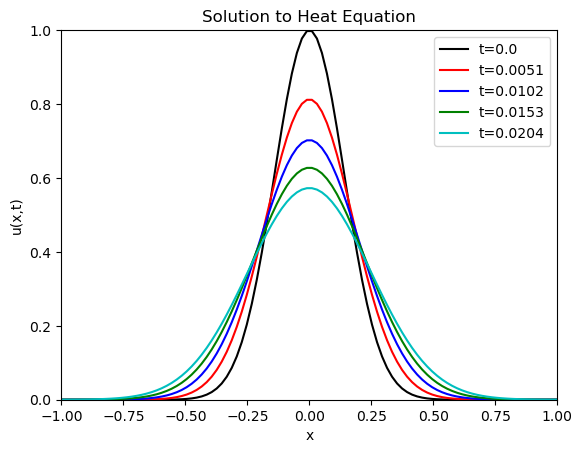

In [5]:
# Compute Heat Equation Solution using Forward Euler and 2nd-order Centered Approximations
import numpy
import matplotlib.pyplot as plt
# Spatial discretization
m = 100
x = numpy.linspace(-1.0, 1.0, m)          # Membuat array titik spasial dari -1 hingga 1 sebanyak m titik
delta_x = 2.0 / (m - 1.0)                 # Menghitung jarak antar titik spasial (step size)

# Time discretization
delta_t = 0.5 * delta_x**2                # Menghitung step waktu (memenuhi syarat stabilitas CFL)
N = 101
t = numpy.arange(0.0, N * delta_t, delta_t)  # Membuat array waktu dari 0 hingga N*delta_t

# Solution array
U = numpy.empty((N + 1, m))              # Membuat array kosong untuk menyimpan solusi U(t, x)

# Initial and boundary conditions
U[0, :] = numpy.exp(-x**2 / 0.2**2)     # Menetapkan kondisi awal berupa fungsi Gaussian
g_0 = lambda t: 0.0                      # Mendefinisikan kondisi batas kiri (x = -1) = 0
g_1 = lambda t: 0.0                      # Mendefinisikan kondisi batas kanan (x = 1) = 0

# Time stepping loop
for n in range(len(t)):                  # Iterasi maju pada setiap langkah waktu
    for i in range(1, len(x) - 1):      # Iterasi pada setiap titik interior (bukan batas)
        U[n+1, i] = U[n, i] + delta_t / delta_x**2 * (U[n, i-1] - 2.0 * U[n, i] + U[n, i+1])
        # Skema Forward Euler + aproksimasi turunan kedua orde-2 (finite difference)

    # Boundaries
    U[n+1, 0] = U[n, 0] + delta_t / delta_x**2 * (g_0(t[n]) - 2.0 * U[n, 0] + U[n, 1]) # Memperbarui nilai batas kiri menggunakan kondisi batas g_0
    U[n+1, -1] = U[n, -1] + delta_t / delta_x**2 * (U[n, -2] - 2.0 * U[n, -1] + g_1(t[n])) # Memperbarui nilai batas kanan menggunakan kondisi batas g_1

# Plot a few solutions
colors = ['k', 'r', 'b', 'g', 'c']      
fig = plt.figure()                        
axes = fig.add_subplot(1, 1, 1)          
for (i, n) in enumerate((0, 25, 50, 75, 100)):   # Iterasi pada indeks waktu yang dipilih untuk divisualisasikan
    axes.plot(x, U[n, :], colors[i], label='t=%s' % numpy.round(t[n], 4))
    # Memplot solusi U pada waktu ke-n dengan warna dan label waktu
    axes.set_xlabel("x")                 # Menetapkan label sumbu x
    axes.set_ylabel("u(x,t)")          
    axes.set_title("Solution to Heat Equation")  
    axes.set_xlim([-1, 1])              # Menetapkan batas tampilan sumbu x
    axes.set_ylim([0.0, 1.0])          

axes.legend()                            
plt.show()                              

Untuk Metode Crank-Nicholson, kita mengetahui bahwa metode trapesium bersifat stabil secara absolut, sehingga kita dapat memilih nilai $\Delta t$ berapapun. Namun, jika $\Delta t$ terlalu besar, kita mungkin akan kehilangan akurasi, sehingga kita perlu sedikit berhati-hati dalam menggunakan metode ini. Secara umum, kita dapat memilih $\Delta t = \mathcal{O}(\Delta x)$ untuk mendapatkan solusi yang cukup baik.

delta_x = 0.020202020202020204
delta_t = 0.010101010101010102


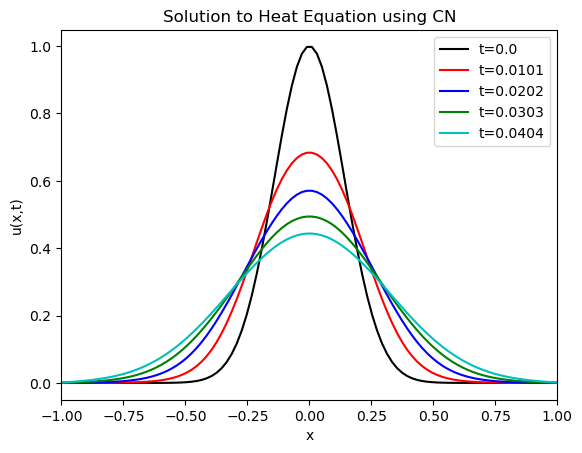

In [6]:
import scipy.sparse as sparse                    # Mengimport library untuk matriks jarang (sparse)
import scipy.sparse.linalg as linalg             # Mengimport library solver aljabar linear untuk matriks jarang
import numpy
import matplotlib.pyplot as plt

# Menghitung Solusi Persamaan Panas menggunakan Crank-Nicholson

# Diskritisasi Spasial
m = 100
x = numpy.linspace(-1.0, 1.0, m)               # Membuat array titik spasial dari -1 hingga 1 sebanyak m titik
delta_x = 2.0 / (m - 1.0)                      # Menghitung jarak antar titik spasial
print("delta_x = %s" % delta_x)                # Mencetak nilai delta_x ke layar

# Diskritisasi Waktu - Memilih delta_t berdasarkan batasan akurasi
C = 0.5
delta_t = C * delta_x                          # Menghitung langkah waktu berdasarkan konstanta akurasi C
t = numpy.arange(0.0, 1.0, delta_t)            # Membuat array waktu dari 0 hingga 1 dengan langkah delta_t
N = len(t)                                      # Menghitung jumlah total langkah waktu
print("delta_t = %s" % delta_t)                # Mencetak nilai delta_t ke layar

# Array Solusi
U = numpy.empty((N + 1, m))                    # Membuat array kosong untuk menyimpan solusi U(t, x)

# Kondisi Awal dan Kondisi Batas
U[0, :] = numpy.exp(-x**2 / 0.2**2)           # Menetapkan kondisi awal berupa fungsi Gaussian
g_0 = lambda t: 0.0                            # Mendefinisikan kondisi batas kiri (x = -1) bernilai 0
g_1 = lambda t: 0.0                            # Mendefinisikan kondisi batas kanan (x = 1) bernilai 0

# Membangun Matriks Penyelesaian
r = numpy.ones(m) * delta_t / (2.0 * delta_x**2)        # Menghitung koefisien r untuk skema Crank-Nicholson
A = sparse.spdiags([-r, 1.0 + 2.0 * r, -r], [-1, 0, 1], m, m).tocsr() # Membangun matriks sparse A (sisi kiri/implisit) dengan diagonal -r, 1+2r, -r
B = sparse.spdiags([r, 1.0 - 2.0 * r, r], [-1, 0, 1], m, m).tocsr() # Membangun matriks sparse B (sisi kanan/eksplisit) dengan diagonal r, 1-2r, r

# Loop Penelusuran Waktu
for n in range(len(t)-1):                      # Iterasi maju pada setiap langkah waktu
    # Menyusun sisi kanan persamaan
    b = B.dot(U[n, :])                         # Menghitung vektor sisi kanan dengan perkalian matriks B dan U[n]
    b[0] += delta_t / (2.0 * delta_x**2) * (g_0(t[n]) + g_0(t[n+1])) # batas kiri pada sisi kanan
    b[-1] += delta_t / (2.0 * delta_x**2) * (g_1(t[n]) + g_1(t[n+1]))# batas kanan pada sisi kanan

    # Menyelesaikan sistem persamaan
    U[n+1, :] = linalg.spsolve(A, b)         

# Menampilkan beberapa solusi
colors = ['k', 'r', 'b', 'g', 'c']           
fig = plt.figure()                              
axes = fig.add_subplot(1, 1, 1)                
for (i, n) in enumerate((0, 1, 2, 3, 4)):     # Iterasi pada indeks waktu yang dipilih untuk ditampilkan
    axes.plot(x, U[n, :], colors[i], label='t=%s' % numpy.round(t[n], 4))
    # Memplot solusi U pada waktu ke-n dengan warna dan label waktu
    axes.set_xlabel("x")                       # Menetapkan label sumbu x
    axes.set_ylabel("u(x,t)")                  
    axes.set_title("Solution to Heat Equation using CN") 
    axes.set_xlim([-1, 1])                     

axes.legend()                                 
plt.show()                                    

Hal ini memunculkan pertanyaan tentang bagaimana kita mempertimbangkan kestabilan dengan dua parameter yang bervariasi, yaitu $\Delta t$ dan $\Delta x$. Metode garis (method of lines) memisahkan masalah menjadi pertimbangan masalah spasial dan temporal, yang sangat membantu (dan kita akan terus menggunakan pendekatan ini). Namun, pendekatan ini tidak menceritakan keseluruhan gambaran, karena beberapa suku dari masing-masing aproksimasi dapat saling menghilangkan satu sama lain. Hal ini dapat terjadi ketika deret Taylor dan substitusi yang sesuai dari PDE beserta turunan-turunannya saling meniadakan satu sama lain.